### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
import statsmodels.api as sm
from scipy import stats
import pymannkendall as mk
import dyndowntools.util as du

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/SNAP"
filepattern_ERA5 = 'wind_{airport}_1980_2019_{resolution}.csv'
filepattern_ERA5_orig = 'era5_{airport}_wsp_1981_2020_monthly.csv'
filepattern_station = "alaska_airports_hourly_winds_{ioac}.csv"

In [ ]:
stations = {
    "ANC_PANC": "PANC",
    "FAI_PAFA": "PAFA",
    "UTQ_PABR": "PABR",
    "BTH_PABE": "PABE"
}
locations = {
    "ANC_PANC": "Anchorage",
    "FAI_PAFA": "Fairbanks",
    "UTQ_PABR": "Utqiaġvik",
    "BTH_PABE": "Bethel"   
}
startdate = '1980-01-01'
enddate = '2019-12-31'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']
teststation = 'FAI_PAFA'

### Functions

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5.format(airport=station, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res].rename(columns={'wspd10': f"wspd10_{res}", 'wdir10': f"wdir10_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km']['wspd10_12km'] = dfs['12km']['wspd10_12km']
    dfs['4km']['wdir10_12km'] = dfs['12km']['wdir10_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    return pd.read_csv(
        stationdir / filepattern_station.format(ioac=stations[station]))

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station)
    stationdf = get_dataframe_station(station)
    stationdf['ws'] = stationdf['ws'] / 2.237 
    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.set_index('ts', inplace=True)
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF, kind='linear'):
    output = []
    for variable in ('wspd10_orig', 'wspd10_4km', 'wspd10_12km', 'ws'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            Z = monthlyDF.query(f'month == {mth}')['ws']

            r_value, tau_value, rmse, bias = None, None, None, None
            if kind=='linear':
                slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            elif kind=='mannkendall':
                _, _, p_value, _, tau_value, _, _, slope, _ = mk.original_test(Y)
            mean = Y.mean()
            std = Y.std()
            if variable != f'ws':
                rmse = du.rmse(Y, Z)
                bias = (Y-Z).mean()
            output.append({
                "location": stations[teststation],
                'variable': variable,
                'month': mth, 
                'mean_monthly': mean, 
                'std_monthly': std,
                'rmse_monthly': rmse,
                'bias_monthly': bias,
                'trend': slope, 
                'p_value': p_value, 
                'kendall_tau': tau_value,
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(hourlyDF, 
                startdate=startdate, enddate=enddate):
    hourlyDF = hourlyDF.loc[startdate:enddate]
    monthly_avg = hourlyDF[['wspd10_4km', 'wspd10_12km', 'ws']].groupby(
        pd.Grouper(freq='D')).max().groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
get_dataframe('FAI_PAFA')

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
teststation

'FAI_PAFA'

In [ ]:
get_dataframe(teststation)

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
compDF = get_dataframe(teststation)
compDF = compDF.loc[compDF.ws > 0]
print(len(compDF))
monthly_DF = get_monthly(compDF)
monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
    airport=stations[teststation]), skiprows=2)
monthly_DF['wspd10_orig'] = monthly_undownscaled['wsp10'].values 
monthly_DF

211809


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,wspd10_4km,wspd10_12km,ws,year,month,wspd10_orig
1980-01-31,3.445214,3.712607,3.539977,1980,1,3.864
1980-02-29,3.755172,4.048414,4.812634,1980,2,3.124
1980-03-31,3.019839,3.227323,4.270552,1980,3,3.753
1980-04-30,4.143400,4.454567,6.777231,1980,4,3.904
1980-05-31,5.266774,5.480032,8.155508,1980,5,3.523
...,...,...,...,...,...,...
2019-08-31,4.149419,4.160000,5.074625,2019,8,2.770
2019-09-30,3.341733,3.607600,4.266726,2019,9,3.382
2019-10-31,3.490452,3.881742,4.145673,2019,10,3.273
2019-11-30,3.458667,4.180567,3.924452,2019,11,3.344


In [ ]:
get_stats(teststation, monthly_DF)

[{'location': 'PAFA',
  'variable': 'wspd10_orig',
  'month': 1,
  'mean_monthly': 3.2817250000000002,
  'std_monthly': 0.391486253319911,
  'rmse_monthly': 0.640995717840304,
  'bias_monthly': 0.23420463615582507,
  'trend': -0.005377016885553471,
  'p_value': 0.32229447718867776,
  'kendall_tau': None,
  'r_value': -0.16056695981598473},
 {'location': 'PAFA',
  'variable': 'wspd10_orig',
  'month': 2,
  'mean_monthly': 3.230225,
  'std_monthly': 0.3955371866533424,
  'rmse_monthly': 0.8049899307758173,
  'bias_monthly': -0.16354935502204468,
  'trend': 0.008274202626641653,
  'p_value': 0.12830214161808226,
  'kendall_tau': None,
  'r_value': 0.2445513884654959},
 {'location': 'PAFA',
  'variable': 'wspd10_orig',
  'month': 3,
  'mean_monthly': 3.3261249999999998,
  'std_monthly': 0.24587063384988372,
  'rmse_monthly': 1.105486711251523,
  'bias_monthly': -0.998917361510637,
  'trend': 0.0038391181988742967,
  'p_value': 0.25958417074842244,
  'kendall_tau': None,
  'r_value': 0.1825

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')['ws']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.020028839927849037, 44.81017138408087, 0.0003104972875426793)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10_orig', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=teststation)

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 10)
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette
palette[3] = palette[7]
palette = palette[:4]
palette
# palette = sns.color_palette("Set2", 3)
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

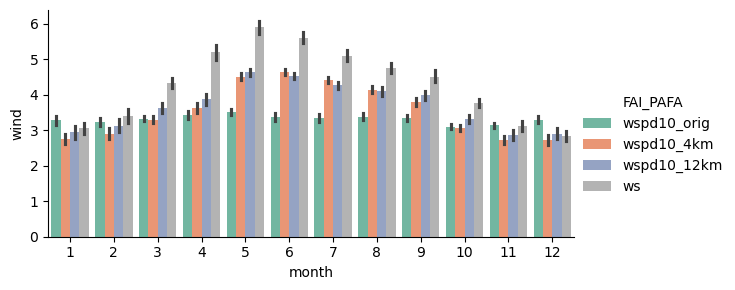

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="wind", 
            hue=teststation, palette=palette, width=0.85, height=3, aspect=2)
# g._legend.remove()

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/667053105.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0.5, 1.0, 'teststation - dates with > 0 wind speed')

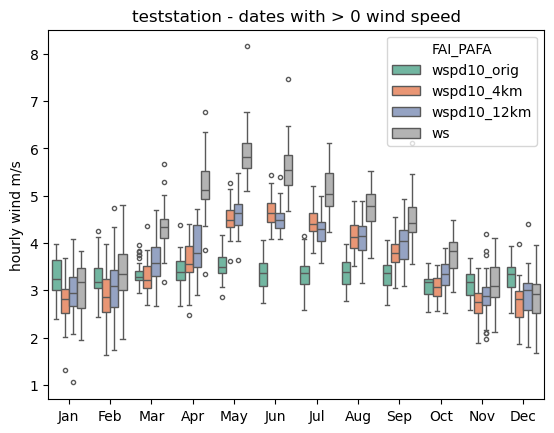

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=teststation, palette=palette, legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('hourly wind m/s')
g.set_title(f"teststation - dates with > 0 wind speed")

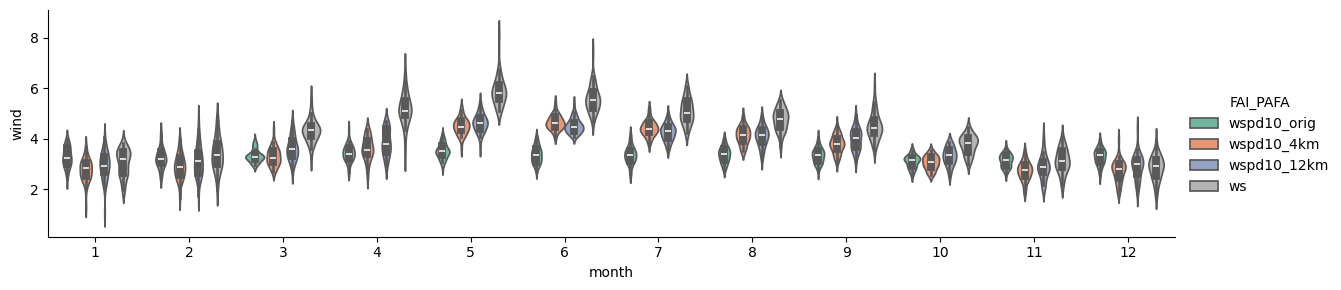

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=4)


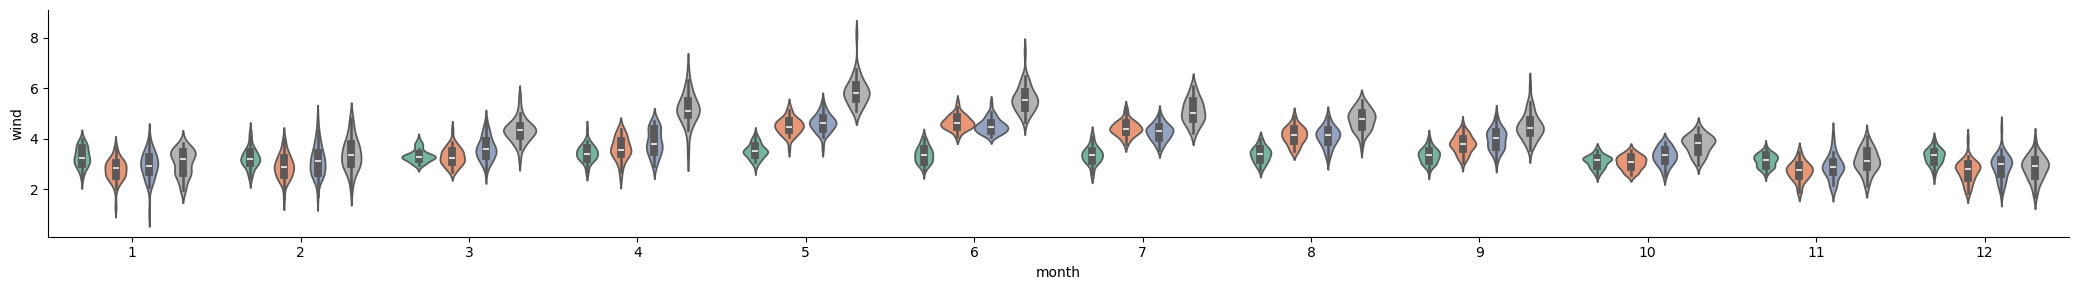

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

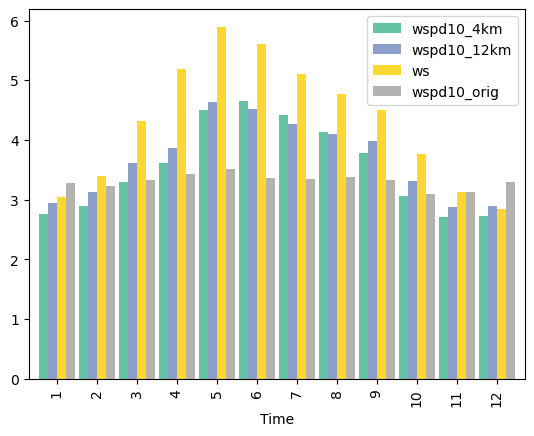

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1223933632.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1223933632.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWa

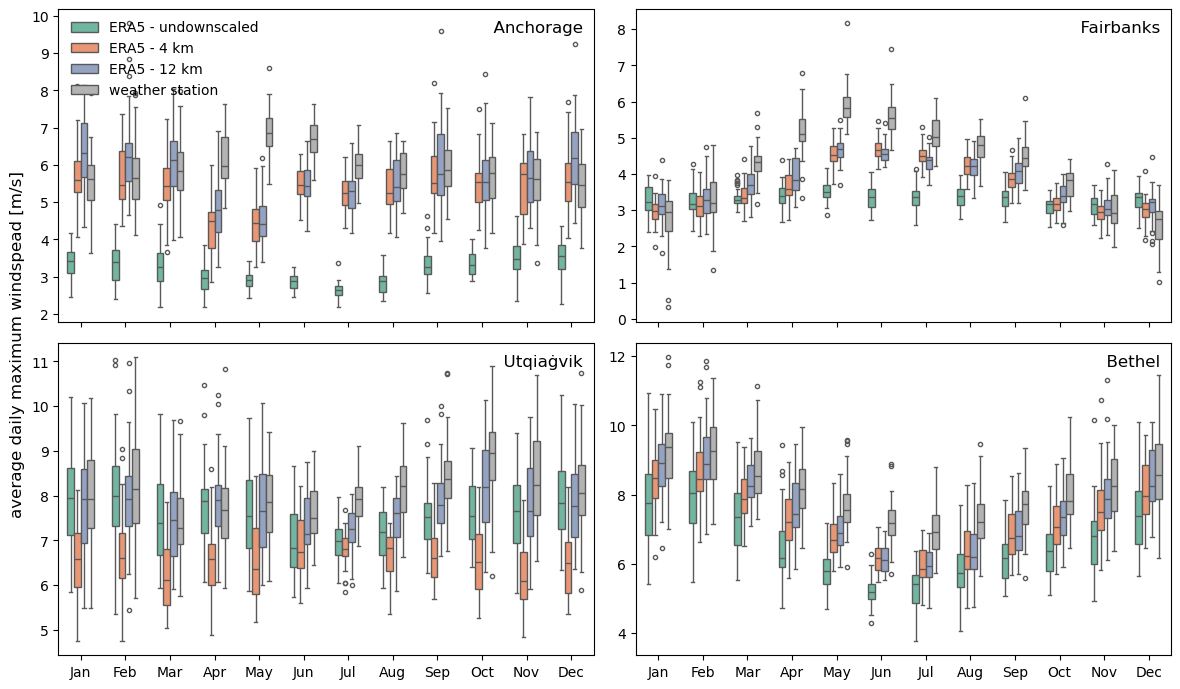

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
    airport=stations[station]), skiprows=2)
    monthly_DF['wspd10_orig'] = monthly_undownscaled['wsp10'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10_orig', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=station, palette=palette, width=0.6, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    # if ii%2:
    #     g.set_ylabel('')
    # else:
    #     g.set_ylabel('')
    ax.set_title('  ' + location + '  ', loc='right', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - undownscaled', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.supylabel('average daily maximum windspead [m/s]')
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.98), frameon=False)
plt.tight_layout()

In [ ]:
fn = f"wind_stations_monthly_distribution_box_{startdate[:4]}-{enddate[:4]}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
        airport=stations[teststation]), skiprows=2)
    monthly_DF['wspd10_orig'] = monthly_undownscaled['wsp10'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF, kind='mannkendall'))


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34716/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF['trend'] = resultsDF['trend'] * 10
resultsDF

,location,variable,month,mean_monthly,std_monthly,rmse_monthly,bias_monthly,trend,p_value,kendall_tau,r_value
0,PANC,wspd10_orig,1,3.281725,0.391486,2.428501,-2.297655,-0.063810,0.268360,-0.123077,None
1,PANC,wspd10_orig,2,3.230225,0.395537,2.691169,-2.481863,0.083333,0.145288,0.161538,None
2,PANC,wspd10_orig,3,3.326125,0.245871,2.696692,-2.566722,0.029434,0.234642,0.132051,None
3,PANC,wspd10_orig,4,3.426475,0.330919,2.798689,-2.707548,0.097696,0.016919,0.264103,None
4,PANC,wspd10_orig,5,3.510575,0.293487,3.397660,-3.326206,-0.007681,0.870420,-0.019231,None
...,...,...,...,...,...,...,...,...,...,...,...
187,PABE,ws,8,7.349424,0.850248,NaN,NaN,0.060138,0.600072,0.058974,None
188,PABE,ws,9,7.646334,0.792650,NaN,NaN,-0.109098,0.388558,-0.096154,None
189,PABE,ws,10,7.990036,0.860739,NaN,NaN,-0.059679,0.770840,-0.033333,None
190,PABE,ws,11,8.261953,0.972037,NaN,NaN,0.014984,0.934999,0.010256,None


In [ ]:
# tableDF = resultsDF.query('variable != "wspd10_12km"')
tableDF = resultsDF
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(4).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


In [ ]:
tableDF

,location,variable,month,mean_monthly,std_monthly,rmse_monthly,bias_monthly,trend,p_value,kendall_tau,r_value,ID,strtrend,sigtrend
0,PANC,wspd10_orig,1,3.281725,0.391486,2.428501,-2.297655,-0.063810,0.268360,-0.123077,None,PANC: wspd10_orig,-0.0638,-0.0638
1,PANC,wspd10_orig,2,3.230225,0.395537,2.691169,-2.481863,0.083333,0.145288,0.161538,None,PANC: wspd10_orig,0.0833,0.0833
2,PANC,wspd10_orig,3,3.326125,0.245871,2.696692,-2.566722,0.029434,0.234642,0.132051,None,PANC: wspd10_orig,0.0294,0.0294
3,PANC,wspd10_orig,4,3.426475,0.330919,2.798689,-2.707548,0.097696,0.016919,0.264103,None,PANC: wspd10_orig,0.0977,0.0977 (**)
4,PANC,wspd10_orig,5,3.510575,0.293487,3.397660,-3.326206,-0.007681,0.870420,-0.019231,None,PANC: wspd10_orig,-0.0077,-0.0077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,PABE,ws,8,7.349424,0.850248,NaN,NaN,0.060138,0.600072,0.058974,None,PABE: ws,0.0601,0.0601
188,PABE,ws,9,7.646334,0.792650,NaN,NaN,-0.109098,0.388558,-0.096154,None,PABE: ws,-0.1091,-0.1091
189,PABE,ws,10,7.990036,0.860739,NaN,NaN,-0.059679,0.770840,-0.033333,None,PABE: ws,-0.0597,-0.0597
190,PABE,ws,11,8.261953,0.972037,NaN,NaN,0.014984,0.934999,0.010256,None,PABE: ws,0.015,0.015


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: ws,0.0561,0.1022,-0.252 (*),-0.0156,0.1392,-0.0026,0.0538,0.0601,-0.1091,-0.0597,0.015,-0.013
PABE: wspd10_12km,0.0213,0.1153,-0.2034 (*),0.0833,-0.002,-0.0578,-0.0107,-0.1083,-0.1853,0.0916,-0.0112,-0.1522
PABE: wspd10_4km,-0.0005,0.1113,-0.2172 (*),0.0771,-0.0085,-0.0449,-0.0167,-0.108,-0.1558,0.1093,0.0086,-0.1583
PABE: wspd10_orig,-0.0638,0.0833,0.0294,0.0977 (**),-0.0077,-0.01,-0.0064,-0.0889,-0.0112,0.036,0.0452,0.0086
PABR: ws,0.1689,0.4011 (**),0.1541,0.0619,-0.0512,0.1291,0.0569,-0.0369,-0.0886,0.3317 (**),0.4364 (**),0.1381
PABR: wspd10_12km,-0.0995,0.2423,0.0636,0.233,-0.0683,0.1357,0.1361 (*),0.1318,-0.0079,0.4916 (**),0.1118,-0.2192
PABR: wspd10_4km,-0.0484,0.203 (*),0.034,0.2007 (*),0.0053,0.1302,-0.0101,-0.0041,-0.0561,0.3217 (**),0.0273,-0.1707
PABR: wspd10_orig,-0.0638,0.0833,0.0294,0.0977 (**),-0.0077,-0.01,-0.0064,-0.0889,-0.0112,0.036,0.0452,0.0086
PAFA: ws,-0.0036,-0.0412,-0.0371,-0.011,-0.1183 (*),-0.1921 (**),-0.2337 (**),-0.2044 (**),-0.1899 (**),-0.0904 (*),0.0652,0.0565


In [ ]:
rmsetable = tableDF.pivot(index='ID', columns='month', values='rmse_monthly')
rmsetable.columns = [calendar.month_abbr[ii] for ii in rmsetable.columns]
rmsetable.dropna(inplace=True)
rmsetable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: wspd10_12km,0.765289,0.782406,0.812592,0.766261,0.894494,1.159463,1.192105,1.134326,0.856490,0.820574,0.724205,0.802502
PABE: wspd10_4km,1.096885,1.028229,1.146395,1.054510,1.094331,1.176266,1.192071,1.119163,0.917851,1.015769,0.929912,0.952906
PABE: wspd10_orig,6.085897,6.156178,5.507664,4.800862,4.306649,3.905317,3.750819,4.068869,4.392578,4.959140,5.219864,5.446653
PABR: wspd10_12km,0.708008,0.779466,0.623853,0.635756,0.627550,0.581081,0.823827,0.919839,0.747670,0.843437,1.000192,0.673815
PABR: wspd10_4km,1.598227,1.739666,1.363762,1.277440,1.395833,0.902345,1.148190,1.573643,1.822266,2.265878,2.262104,1.764677
PABR: wspd10_orig,4.883489,5.214382,4.239795,4.332182,4.419491,4.364000,4.590715,4.844790,5.180859,5.782813,5.350723,4.961067
PAFA: wspd10_12km,0.657205,0.429442,0.728034,1.350151,1.295505,1.122405,0.894958,0.687813,0.595016,0.421538,0.321109,0.722392
PAFA: wspd10_4km,0.612421,0.470594,0.958432,1.589378,1.416351,1.010553,0.755359,0.635316,0.757676,0.618856,0.362983,0.605123
PAFA: wspd10_orig,0.983003,0.859343,1.097687,1.869551,2.456323,2.335287,1.859641,1.476231,1.323545,0.762501,0.550737,0.988801


In [ ]:
biastable = tableDF.pivot(index='ID', columns='month', values='bias_monthly')
biastable.columns = [calendar.month_abbr[ii] for ii in biastable.columns]
biastable.dropna(inplace=True)
biastable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: wspd10_12km,-0.392886,-0.181981,-0.435485,-0.465674,-0.745004,-1.055289,-1.075513,-1.027094,-0.696666,-0.636838,-0.350868,-0.078768
PABE: wspd10_4km,-0.837288,-0.597514,-0.822368,-0.829348,-0.962787,-1.072647,-1.072744,-1.006954,-0.773779,-0.864147,-0.703322,-0.474287
PABE: wspd10_orig,-5.968902,-6.050660,-5.426305,-4.711984,-4.217834,-3.843495,-3.651291,-3.975549,-4.309584,-4.891911,-5.126028,-5.313294
PABR: wspd10_12km,-0.191145,-0.345153,0.052863,0.154757,-0.132597,-0.309189,-0.671339,-0.729695,-0.567219,-0.574974,-0.603100,-0.287371
PABR: wspd10_4km,-1.470214,-1.604465,-1.240841,-1.137768,-1.281773,-0.785722,-1.074038,-1.496725,-1.756707,-2.182770,-2.120493,-1.657289
PABR: wspd10_orig,-4.741830,-5.048832,-4.133210,-4.244405,-4.328975,-4.297880,-4.546413,-4.794045,-5.100074,-5.683145,-5.233109,-4.851951
PAFA: wspd10_12km,0.395296,0.034112,-0.576236,-1.263766,-1.223077,-1.029466,-0.772484,-0.599983,-0.460618,-0.314663,0.052854,0.567625
PAFA: wspd10_4km,0.229650,-0.174261,-0.895605,-1.520973,-1.340359,-0.893739,-0.607559,-0.541606,-0.656364,-0.557436,-0.086414,0.414407
PAFA: wspd10_orig,0.541418,-0.066935,-0.979309,-1.763038,-2.381738,-2.235743,-1.750438,-1.388631,-1.172053,-0.628258,0.121255,0.721293
